In [7]:
import pandas as pd
import numpy as np

In [8]:
file = r'cryptos.csv'
data = pd.read_csv(file, index_col="Date", parse_dates=True)

In [9]:
log_returns = np.log(data / data.shift(1))

In [10]:
log_returns.dropna(inplace=True)

In [11]:
from statsmodels.tsa.stattools import adfuller

# **CORRELACIONES**

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

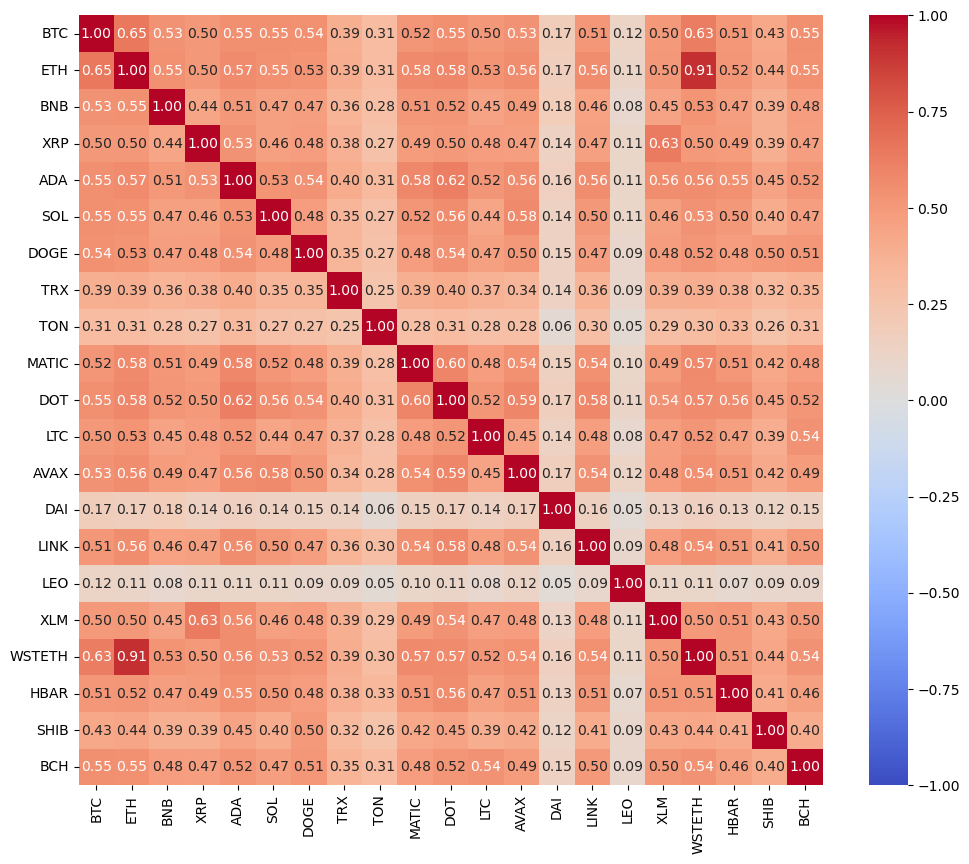

In [13]:
plt.figure(figsize=(12, 10))
sns.heatmap(log_returns.corr(method='kendall'), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.savefig("correlacion-kendall.svg", format='svg', bbox_inches='tight')
plt.show()

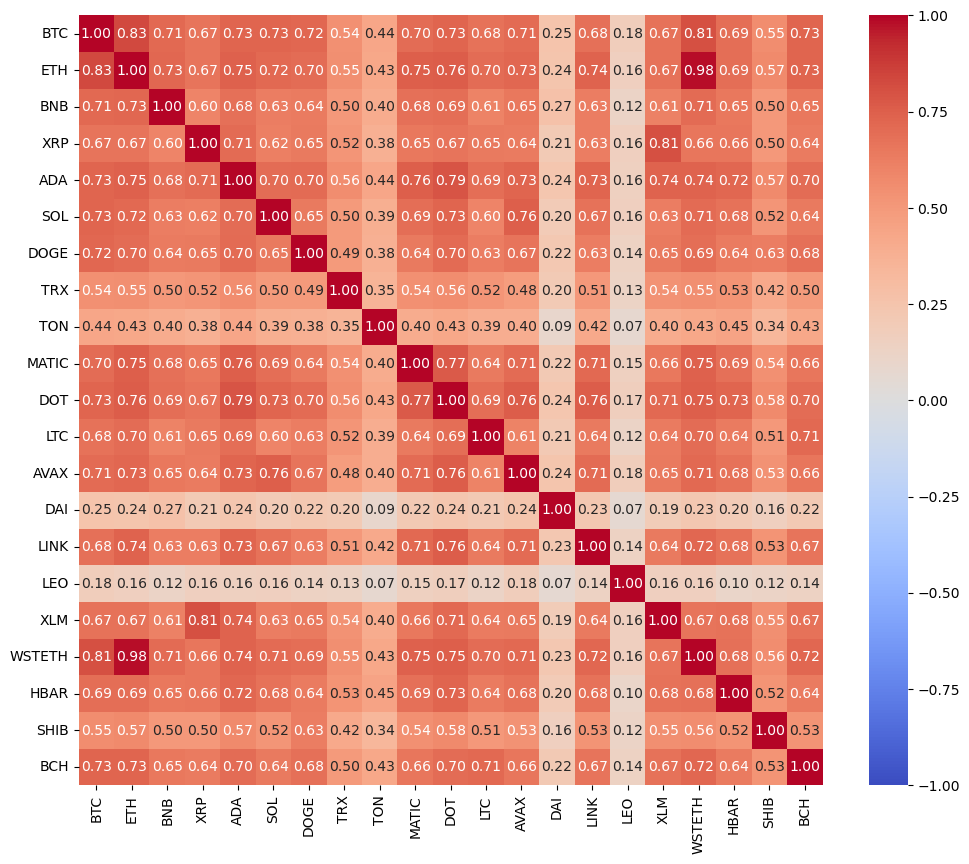

In [14]:
plt.figure(figsize=(12, 10))
sns.heatmap(log_returns.corr(method='spearman'), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.savefig("correlacion-spearman.svg", format='svg', bbox_inches='tight')
plt.show()

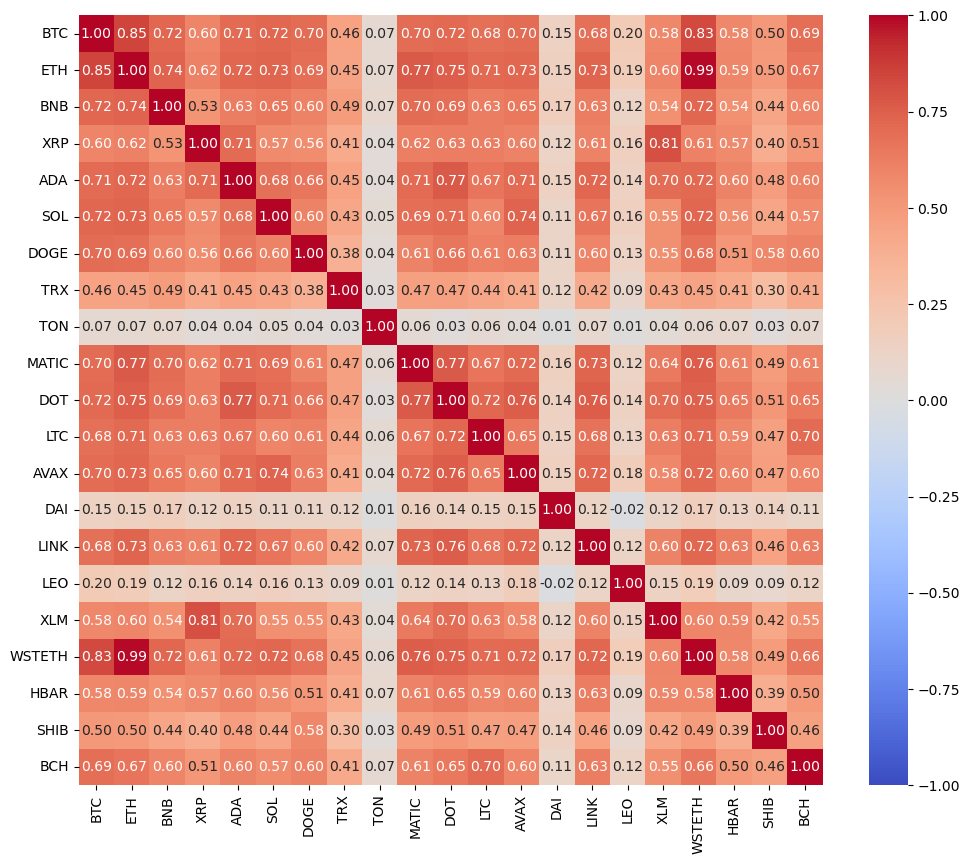

In [15]:
plt.figure(figsize=(12, 10))
sns.heatmap(log_returns.corr(method='pearson'), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.savefig("correlacion-pearson.svg", format='svg', bbox_inches='tight')
plt.show()

Nos quedamos con la Pearson

In [16]:
corr=log_returns.corr(method='pearson')

# **GRAFOS**

In [17]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# **CONECTARLOS SI TIENEN CORRELACION SPEARMAN MAYOR A 0.7**

In [18]:
G = nx.Graph()

In [19]:
corr_num = 0.7

In [20]:
# agregar los nodos y las aristas
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > corr_num:  # si la correlación es mayor que corr_num
            G.add_edge(corr.columns[i], corr.columns[j], weight=corr.iloc[i, j])
        else:   # si no hay correlación, no se añade solo el nodo
            G.add_node(corr.columns[i])
            G.add_node(corr.columns[j])

In [21]:
# el color del nodo depende de su grado
node_colors = [G.degree(node) for node in G.nodes()]

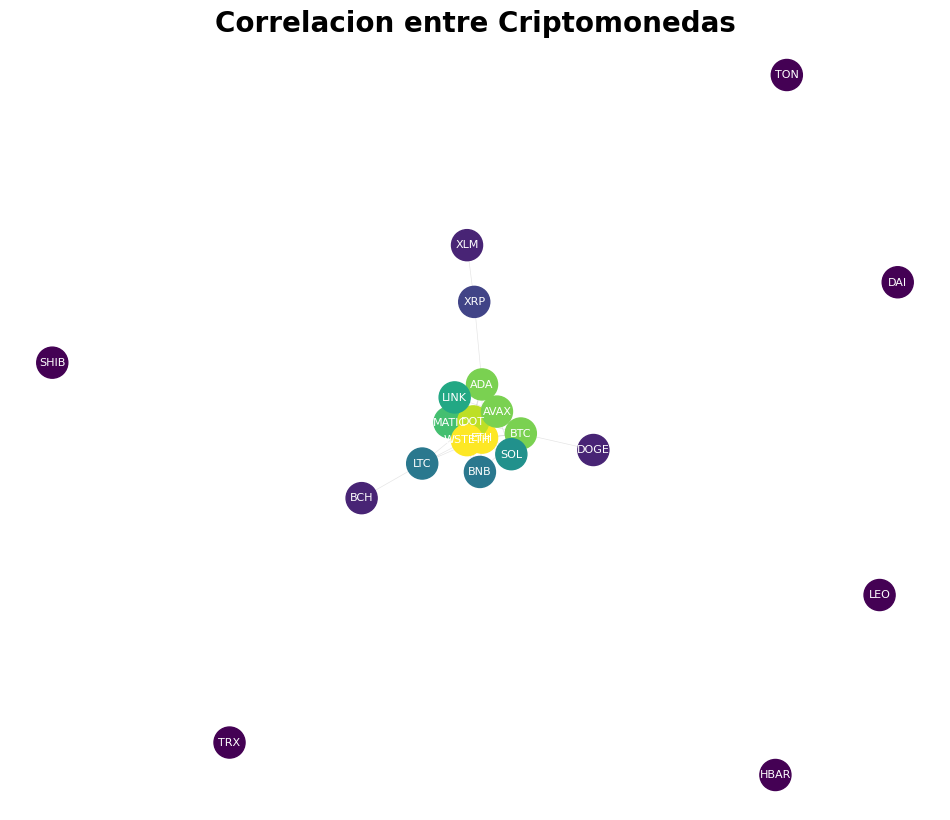

In [22]:
pos = nx.spring_layout(G)
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500)
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.1)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white')
plt.axis('off')
plt.title("Correlacion entre Criptomonedas", fontsize=20, fontweight='bold')
plt.savefig("correlacion.svg", format='svg', bbox_inches='tight')
plt.show()

## **CONECTARLOS Y ALEJARLOS DEPENDIENDO DE LOS PESOS**

In [23]:
G = nx.Graph()

In [24]:
# mientras menos correlacion, mas distancia
dist_corr = 1 - abs(corr)

In [25]:
# agregar las aristas con pesos
for i in range(len(corr.columns)):
    for j in range(i):
        G.add_edge(dist_corr.columns[i], dist_corr.columns[j], weight=dist_corr.iloc[i, j])

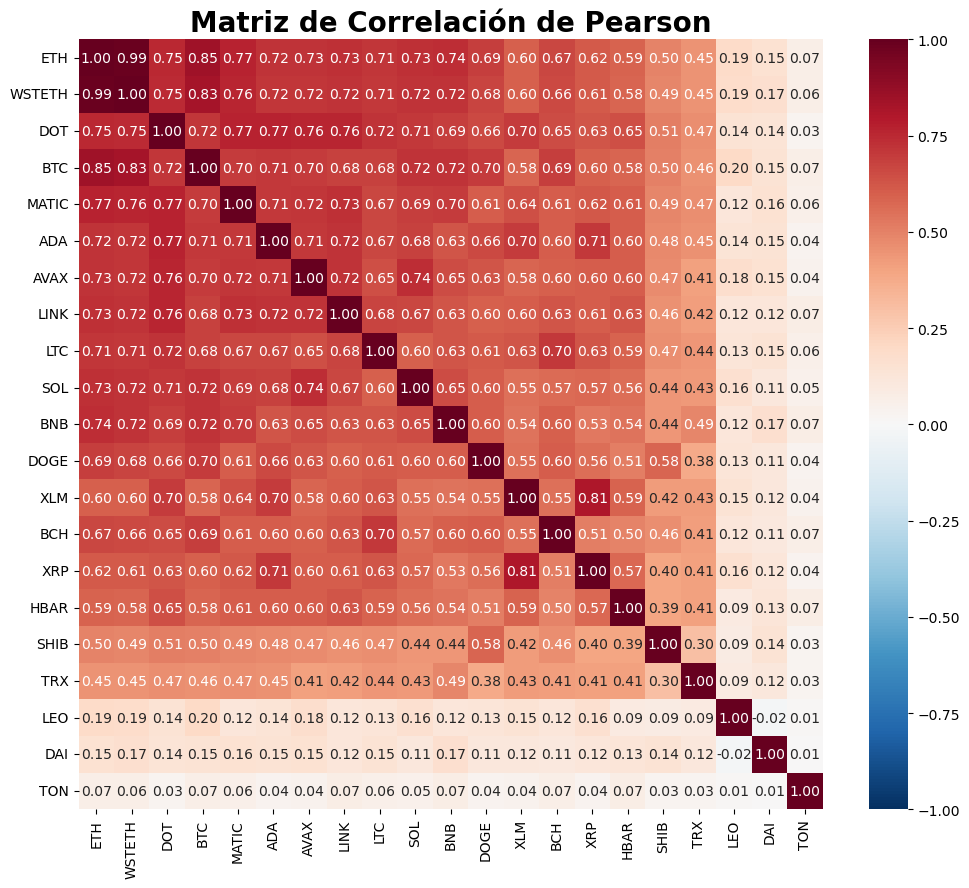

In [35]:
# Compute the sum of absolute correlations for each row
row_sum = corr.abs().sum(axis=1)
# Sort the labels based on the sum (highest sum first)
sorted_labels = row_sum.sort_values(ascending=False).index
# Reorder the correlation matrix
sorted_corr = corr.loc[sorted_labels, sorted_labels]

plt.figure(figsize=(12, 10))
sns.heatmap(sorted_corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Matriz de Correlación de Pearson", fontsize=20, fontweight='bold')
plt.savefig("correlacion-pearson-sorted-abs.svg", format='svg', bbox_inches='tight')
plt.show()

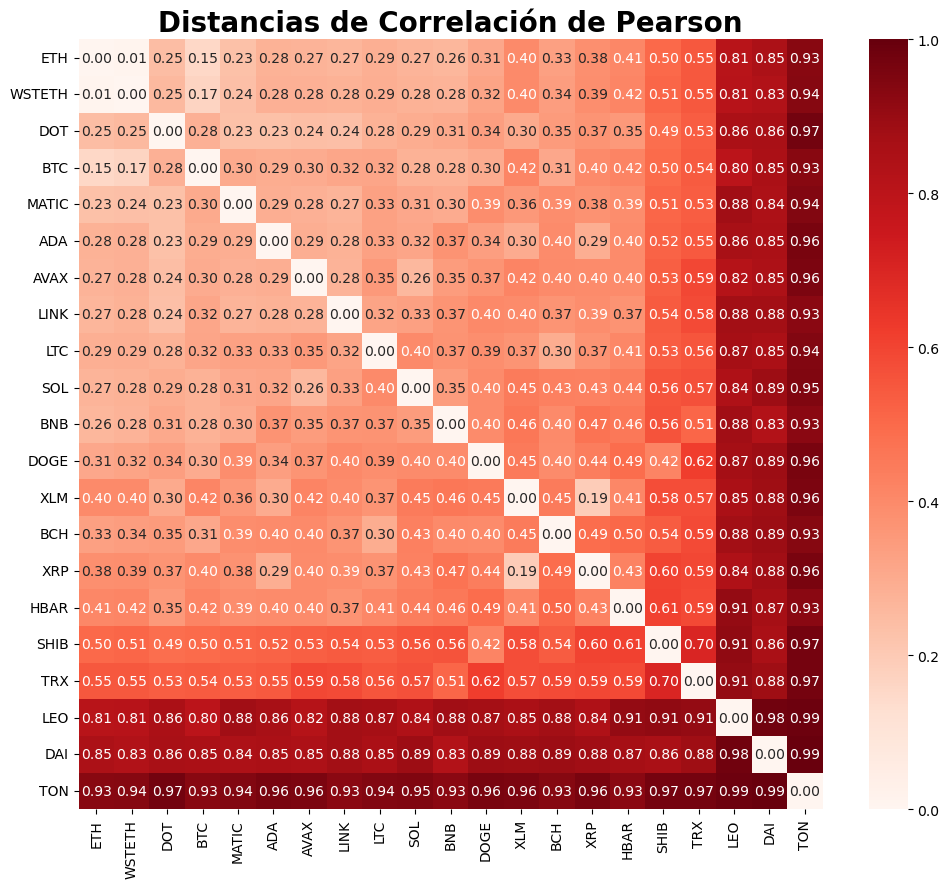

In [34]:
# reorder the distance matrix
sorted_dist_corr = dist_corr.loc[sorted_labels, sorted_labels]

plt.figure(figsize=(12, 10))
sns.heatmap(sorted_dist_corr, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1)
plt.title("Distancias de Correlación de Pearson", fontsize=20, fontweight='bold')
plt.savefig("distancia-pearson-dendrogram.svg", format='svg', bbox_inches='tight')
plt.show()

In [22]:
classification = {
    'BTC': 'Mayor Cap. Mercado',
    'ETH': 'Mayor Cap. Mercado',
    'USDT': 'Stablecoins',
    'BNB': 'Mayor Cap. Mercado',
    'USDC': 'Stablecoins',
    'XRP': 'Mayor Cap. Mercado',
    'ADA': 'Mayor Cap. Mercado',
    'SOL': 'Mayor Cap. Mercado',
    'DOGE': 'Memecoins',
    'DAI': 'Stablecoins',
    'TRX': 'Tokens Blockchain',
    'TON': 'Tokens Blockchain',
    'MATIC': 'Tokens Blockchain',
    'DOT': 'Tokens Blockchain',
    'AVAX': 'Tokens Blockchain',
    'STETH': 'Tokens Blockchain',
    'WSTETH': 'Activos Envueltos',
    'SUI': 'Tokens Blockchain',
    'WBTC': 'Activos Envueltos',
    'WTRX': 'Activos Envueltos',
    'LTC': 'Pagos & DeFi',
    'LINK': 'Pagos & DeFi',
    'XLM': 'Pagos & DeFi',
    'HBAR': 'Pagos & DeFi',
    'BCH': 'Pagos & DeFi',
    'SHIB': 'Memecoins',
    'LEO': 'Tokens de Exchange'
}

In [23]:
palette = {
    'Activos Envueltos': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
    'Mayor Cap. Mercado': (1.0, 0.4980392156862745, 0.054901960784313725),
    'Memecoins': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
    'Pagos & DeFi': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
    'Stablecoins': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
    'Tokens Blockchain': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
    'Tokens de Exchange': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902)
}

In [24]:
node_colors = []
for node in G.nodes():
    node_colors.append(palette[classification[node]])

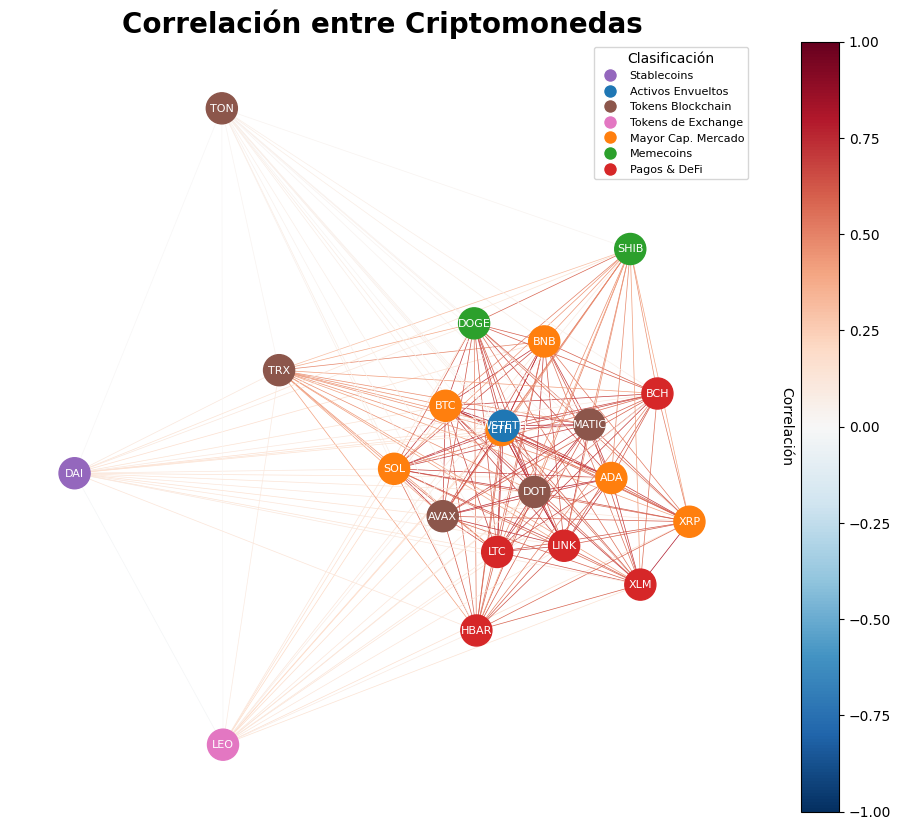

In [49]:
pos = nx.kamada_kawai_layout(G)
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500)
# edge_weights = [G[u][v]['weight'] for u, v in G.edges()]

# Colores
norm = plt.Normalize(vmin=-1, vmax=1)
edge_colors = [cm.RdBu_r(norm(corr.loc[u, v])) for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=0.5, alpha=1)

# add the colorbar 
sm = plt.cm.ScalarMappable(cmap=cm.RdBu_r, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Correlación', rotation=270, labelpad=15)
cbar.ax.yaxis.set_label_position('left')

# Añadir etiquetas de los nodos
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white')
plt.axis('off')
plt.title("Correlación entre Criptomonedas", fontsize=20, fontweight='bold')

# Añadir la leyenda - chat
legend_labels = list(classification.values())
unique_labels = list(set(legend_labels))
handles = []
for label in unique_labels:
    color = palette[label]
    handles.append(plt.Line2D([0], [0], marker='o', color='w', label=label, markerfacecolor=color, markersize=10))
plt.legend(handles=handles, title="Clasificación", loc='upper right', bbox_to_anchor=(1, 1), fontsize=8)

plt.savefig("grafo-correlacion.svg", format='svg', bbox_inches='tight')
plt.show()